# DATA 622: Homework 9
**Author:** Brett Allen (ballen3@umbc.edu)

**Date Completed:** 04/04/2026

## Setup

In [18]:
!python -m pip install -q requests beautifulsoup4 transformers torch sentence-transformers scikit-learn matplotlib seaborn

### Imports

In [40]:
import requests
from bs4 import BeautifulSoup
import torch
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

### Configurations

In [21]:
sns.set_style('darkgrid')

## Questions
Use the article https://apnews.com/article/boeing-aviation-aircraft-air-india-crash-f12b20e65dc57ae655a1e0759b58938f

In [3]:
url = "https://apnews.com/article/boeing-aviation-aircraft-air-india-crash-f12b20e65dc57ae655a1e0759b58938f"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:109.0) Gecko/20100101 Firefox/115.0"
}

In [4]:
# Initiate GET request and check the status code (expecting 200)
response = requests.get(url, headers=headers)
response.status_code

200

In [5]:
# Parse page contents with beautiful soup
soup = BeautifulSoup(response.text, "html.parser")

# Extract paragraphs
paragraphs = soup.find_all("p")
article_text = " ".join([p.get_text() for p in paragraphs])

In [12]:
# Display the first and last quarter of the document
qtr = len(article_text) // 4
print(article_text[:qtr] + '\n...\n' + article_text[-qtr:])


 Copyright 2026 The Associated Press. All Rights Reserved. 
 Copyright 2026 The Associated Press. All Rights Reserved. The Boeing logo is displayed at the company’s factory, Sept. 24, 2024, in Renton, Wash. (AP Photo/Lindsey Wasson, File) 
 ▶ Follow live updates on the Air India plane crash.  The crash of a Boeing 787 passenger jet in India minutes after takeoff on Thursday is putting the spotlight back on a beleaguered manufacturer though it was not immediately clear why the plane crashed.  The Air India 787 went down in the northwestern city of Ahmedabad with more than 240 people aboard shortly after takeoff, authorities said. It was the first fatal crash since the plane, also known as the Dreamliner, went into service in 2011, according to the Aviation Safety Network database. Boeing shares fell more than 4% in afte
...
ring the quarter.  
 The stepped-up government scrutiny and the workers’ strike resulted in Boeing’s aircraft deliveries sliding last year.  Boeing said it supplied

### 1. Classify the sentiment, the intent, and the emotions.

In [13]:
# Helper utilities
def chunk_text(text, max_chars=450):
    """Split text into max_chars chunks, respecting sentence boundaries."""
    sentences = [s.strip() for s in text.split('.') if s.strip()]
    chunks, current = [], ""
    for s in sentences:
        candidate = current + s + '. '
        if len(candidate) > max_chars and current:
            chunks.append(current.strip())
            current = s + '. '
        else:
            current = candidate
    if current:
        chunks.append(current.strip())
    return chunks

def avg_scores(results_per_chunk):
    """Average label scores across all chunks."""
    from collections import defaultdict
    totals, counts = defaultdict(float), defaultdict(int)
    for chunk_result in results_per_chunk:
        items = chunk_result if isinstance(chunk_result, list) else [chunk_result]
        for item in items:
            totals[item['label']] += item['score']
            counts[item['label']] += 1
    return dict(sorted(
        {lbl: totals[lbl] / counts[lbl] for lbl in totals}.items(),
        key=lambda x: x[1], reverse=True
    ))

In [14]:
chunks = chunk_text(article_text)
print(f"Article split into {len(chunks)} chunks.\n")

Article split into 10 chunks.



#### Sentiment

In [50]:
sent_model_name = "distilbert-base-uncased-finetuned-sst-2-english"

In [15]:
print("=== Sentiment ===")
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=sent_model_name,
    truncation=True, 
    max_length=512
)

sentiment_raw = [sentiment_pipe(c)[0] for c in chunks]
sentiment_scores = avg_scores(sentiment_raw)
top_sentiment = next(iter(sentiment_scores))

print(f"Predicted: {top_sentiment}")
for label, score in sentiment_scores.items():
    print(f"  {label}: {score:.4f}")

=== Sentiment ===


Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 2675.91it/s]


Predicted: NEGATIVE
  NEGATIVE: 0.9931
  POSITIVE: 0.9856


#### Intent

In [49]:
intent_model_name = "facebook/bart-large-mnli"

In [16]:
print("=== Intent ===")
intent_pipe = pipeline("zero-shot-classification", model=intent_model_name)
intent_labels = ["news reporting", "investigative journalism", "opinion", "policy analysis", "event analysis"]

intent_raw = [
    intent_pipe(c, candidate_labels=intent_labels)
    for c in chunks
]

intent_scores = avg_scores([
    [{"label": r["labels"][i], "score": r["scores"][i]} for i in range(len(r["labels"]))]
    for r in intent_raw
])

top_intent = next(iter(intent_scores))

print(f"Predicted: {top_intent}")
for label, score in intent_scores.items():
    print(f"  {label}: {score:.4f}")


=== Intent ===


Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 515/515 [00:00<00:00, 2062.43it/s]


Predicted: event analysis
  event analysis: 0.3923
  news reporting: 0.2473
  opinion: 0.1689
  investigative journalism: 0.1114
  policy analysis: 0.0801


#### Emotions

In [51]:
emotion_model_name = "j-hartmann/emotion-english-distilroberta-base"

In [17]:
print("=== Emotions ===")
emotion_pipe = pipeline(
    "text-classification",
    model=emotion_model_name,
    top_k=None, truncation=True, max_length=512
)
emotion_raw = [emotion_pipe(c)[0] for c in chunks]
emotion_scores = avg_scores(emotion_raw)
top_emotion = next(iter(emotion_scores))

print(f"Predicted: {top_emotion}")
for label, score in emotion_scores.items():
    print(f"  {label}: {score:.4f}")

=== Emotions ===


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 12461.15it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Predicted: sadness
  sadness: 0.3805
  neutral: 0.3134
  anger: 0.1371
  fear: 0.0764
  joy: 0.0356
  disgust: 0.0294
  surprise: 0.0277


### 2. Determine how much the article is about technology, aviation, and policies. 

In [22]:
topics = ["technology", "aviation", "policies"]

# NOTE: Using same mode used for intent pipeline
topic_raw = [
    intent_pipe(c, candidate_labels=topics, multi_label=True)
    for c in chunks
]

topic_scores = avg_scores([
    [{"label": r["labels"][i], "score": r["scores"][i]} for i in range(len(r["labels"]))]
    for r in topic_raw
])

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


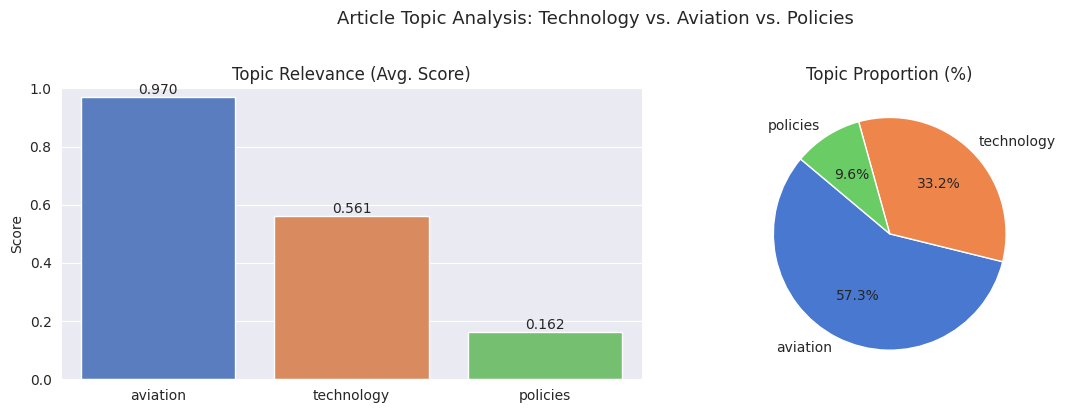

In [25]:
labels = list(topic_scores.keys())
scores = list(topic_scores.values())
total = sum(scores)
percentages = [s / total * 100 for s in scores]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = sns.color_palette("muted", len(labels))

# Bar chart — raw scores
sns.barplot(x=labels, y=scores, hue=labels, palette=palette, legend=False, ax=axes[0])
axes[0].set_title("Topic Relevance (Avg. Score)")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
for i, v in enumerate(scores):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# Pie chart — relative proportions
axes[1].pie(percentages, labels=labels, autopct="%1.1f%%", colors=palette, startangle=140)
axes[1].set_title("Topic Proportion (%)")

plt.suptitle("Article Topic Analysis: Technology vs. Aviation vs. Policies", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
print("\n=== Topic Scores ===")
for label, score in topic_scores.items():
    print(f"  {label:<12} {score:.4f}  ({score/total*100:.1f}%)")


=== Topic Scores ===
  aviation     0.9695  (57.3%)
  technology   0.5614  (33.2%)
  policies     0.1623  (9.6%)


### 3. Use LLMs and one Deep Learning method of your choice to answer the questions. Compare the results.

#### LLM Approach

In [45]:
llm_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

In [28]:
# Initialize LLM
llm_pipe = pipeline(
    "text-generation",
    model=llm_model_name,
    device_map="auto"
)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 338/338 [00:02<00:00, 116.85it/s]


In [29]:
# Obtain sample chunks
sample_chunks = chunks[:5]

In [30]:
sample_chunks

['Copyright 2026 The Associated Press. All Rights Reserved. Copyright 2026 The Associated Press. All Rights Reserved. The Boeing logo is displayed at the company’s factory, Sept. 24, 2024, in Renton, Wash. (AP Photo/Lindsey Wasson, File) \n ▶ Follow live updates on the Air India plane crash.',
 'The crash of a Boeing 787 passenger jet in India minutes after takeoff on Thursday is putting the spotlight back on a beleaguered manufacturer though it was not immediately clear why the plane crashed. The Air India 787 went down in the northwestern city of Ahmedabad with more than 240 people aboard shortly after takeoff, authorities said.',
 'It was the first fatal crash since the plane, also known as the Dreamliner, went into service in 2011, according to the Aviation Safety Network database. Boeing shares fell more than 4% in afternoon trading. The 787 was the first airliner to make extensive use of lithium ion batteries, which are lighter, recharge faster and can hold more energy than other

In [37]:
def llm_generate(pipe, prompt, max_new_tokens=256, temperature=0.3):
    """Generate text and strip the prompt from the output"""
    result = pipe(prompt, max_new_tokens=max_new_tokens, temperature=temperature)
    output = result[0]["generated_text"]
    if prompt in output:
        output = output[output.index(prompt) + len(prompt):]
    return output.strip()

In [32]:
def llm_classify(pipe, chunks, make_prompt, valid_labels):
    """Run LLM on each chunk; return the most frequent valid label predicted."""
    preds = []
    for c in chunks:
        out = llm_generate(pipe, make_prompt(c)).lower()
        match = next((l for l in valid_labels if l.lower() in out), None)
        if match:
            preds.append(match)
    return Counter(preds).most_common(1)[0][0] if preds else valid_labels[0]

##### Sentiment

In [ ]:
# Sentiment
llm_sentiment = llm_classify(
    llm_pipe, sample_chunks,
    lambda c: f"Is the sentiment of this text positive or negative? Answer with one word only.\n\nText: {c}",
    ["POSITIVE", "NEGATIVE", "positive", "negative"]
).upper()

##### Intent

In [ ]:
llm_intent = llm_classify(
    llm_pipe, sample_chunks,
    lambda c: f"What is the intent of this text? Choose one: {', '.join(intent_labels)}. Answer with the label only.\n\nText: {c}",
    intent_labels
)

##### Emotion

In [ ]:
emotion_labels_list = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

llm_emotion = llm_classify(
    llm_pipe, sample_chunks,
    lambda c: f"What emotion does this text express? Choose one: {', '.join(emotion_labels_list)}. Answer with one word only.\n\nText: {c}",
    emotion_labels_list
)

##### Topics

In [38]:
llm_topics = {}
for topic in topics:
    votes = sum(
        1 for c in sample_chunks
        if "yes" in llm_generate(llm_pipe, f"Is this text about {topic}? Answer yes or no.\n\nText: {c}").lower()
    )
    llm_topics[topic] = votes / len(sample_chunks)

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_g

In [52]:
print(f"=== LLM Results ({llm_model_name}) ===")
print(f"  Sentiment : {llm_sentiment}")
print(f"  Intent    : {llm_intent}")
print(f"  Emotion   : {llm_emotion}")
print(f"  Topics    : { {k: f'{v:.2f}' for k, v in llm_topics.items()} }")

=== LLM Results (Qwen/Qwen2.5-1.5B-Instruct) ===
  Sentiment : NEGATIVE
  Intent    : news reporting
  Emotion   : anger
  Topics    : {'technology': '1.00', 'aviation': '1.00', 'policies': '1.00'}


#### Deep Learning Approach

In [46]:
st_model_name = "all-MiniLM-L6-v2"

In [41]:
st_model = SentenceTransformer(st_model_name)

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 1539.47it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [42]:
def st_zero_shot(chunks, labels, descriptions):
    """Classify via average cosine similarity between chunk and label embeddings."""
    label_embs = st_model.encode(descriptions, convert_to_numpy=True)
    chunk_embs = st_model.encode(chunks, convert_to_numpy=True)
    sims = cosine_similarity(chunk_embs, label_embs)  # (n_chunks, n_labels)
    avg = sims.mean(axis=0)
    return dict(sorted(zip(labels, avg), key=lambda x: x[1], reverse=True))

##### Sentiment

In [ ]:
st_sentiment = st_zero_shot(
    chunks, ["POSITIVE", "NEGATIVE"],
    ["positive sentiment, good news, optimistic", "negative sentiment, tragedy, bad news"]
)

##### Intent

In [ ]:
st_intent = st_zero_shot(
    chunks, intent_labels,
    [f"text that is {l}" for l in intent_labels]
)

##### Emotion

In [ ]:
emotion_labels_list = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

st_emotions = st_zero_shot(
    chunks, emotion_labels_list,
    [f"text that expresses {e}" for e in emotion_labels_list]
)

##### Topics

In [ ]:
st_topics = st_zero_shot(
    chunks, topics,
    [f"text about {t}" for t in topics]
)

In [53]:
print(f"=== SentenceTransformer Results ({st_model_name}) ===")
print(f"  Sentiment : {next(iter(st_sentiment))}")
print(f"  Intent    : {next(iter(st_intent))}")
print(f"  Emotion   : {next(iter(st_emotions))}")
print(f"  Topics    : { {k: f'{v:.3f}' for k, v in st_topics.items()} }")

=== SentenceTransformer Results (all-MiniLM-L6-v2) ===
  Sentiment : NEGATIVE
  Intent    : news reporting
  Emotion   : sadness
  Topics    : {'aviation': '0.278', 'technology': '0.070', 'policies': '-0.001'}


#### Compare Results

In [55]:
def short_name(model_name):
    return model_name.split("/")[-1]

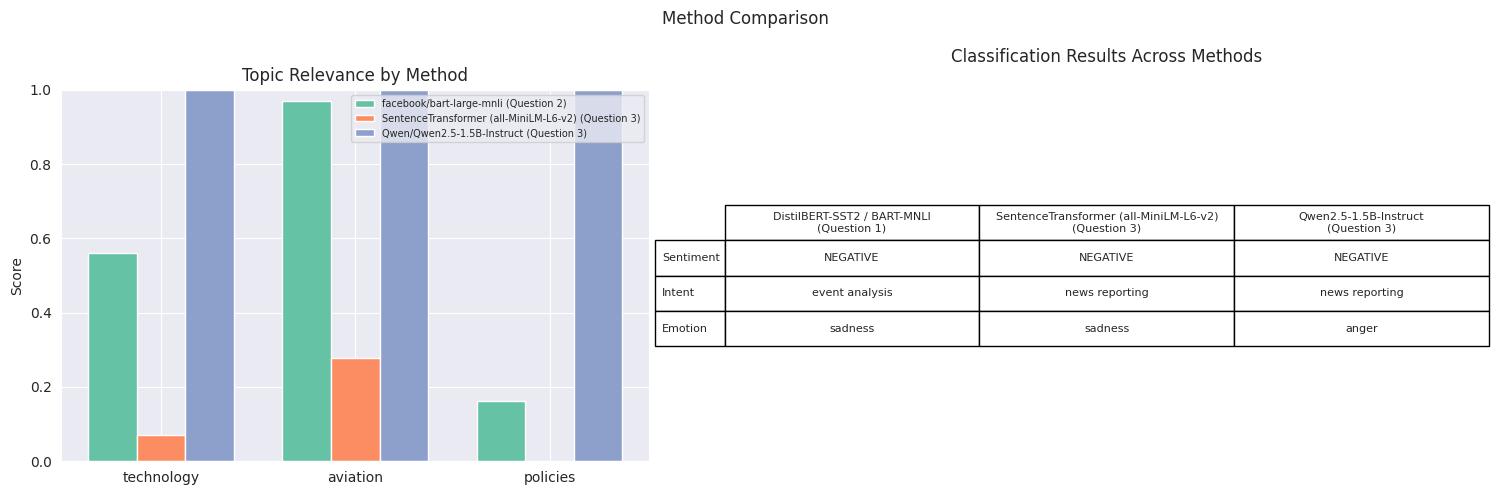

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
method_colors = sns.color_palette("Set2", 3)

# --- Topic relevance: grouped bar chart across all 3 methods ---
topic_comparison = {
    f"{intent_model_name} (Question 2)":              [topic_scores.get(t, 0) for t in topics],
    f"SentenceTransformer ({st_model_name}) (Question 3)": [st_topics.get(t, 0) for t in topics],
    f"{llm_model_name} (Question 3)":                 [llm_topics.get(t, 0) for t in topics],
}
x = np.arange(len(topics))
width = 0.25

for i, (method, vals) in enumerate(topic_comparison.items()):
    axes[0].bar(x + i * width, vals, width, label=method, color=method_colors[i])

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(topics)
axes[0].set_title("Topic Relevance by Method")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=7)

# Question 1 results: summary table
table_data = [
    [top_sentiment,  next(iter(st_sentiment)),  llm_sentiment],
    [top_intent,     next(iter(st_intent)),      llm_intent],
    [top_emotion,    next(iter(st_emotions)),    llm_emotion],
]

sent_display   = "DistilBERT-SST2"
intent_display = "BART-MNLI"
st_display     = short_name(st_model_name)       # "all-MiniLM-L6-v2"
llm_display    = short_name(llm_model_name)      # "Qwen2.5-1.5B-Instruct"

col_labels = [
    f"{sent_display} / {intent_display}\n(Question 1)",
    f"SentenceTransformer ({st_display})\n(Question 3)",
    f"{llm_display}\n(Question 3)",
]

row_labels = ["Sentiment", "Intent", "Emotion"]

axes[1].axis("off")
table = axes[1].table(
    cellText=table_data,
    colLabels=col_labels,
    rowLabels=row_labels,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.3, 2.2)
axes[1].set_title("Classification Results Across Methods", pad=20)

plt.suptitle("Method Comparison", fontsize=12)
plt.tight_layout()
plt.show()

**Observation:** Interestingly the LLM (`Qwen2.5-1.5B-Instruct`) classified the topic for the article as a perfect mix of all three topics (`technology`, `aviation`, and `policies`). This is most likely because the LLM was prompted to classify as yes or no (pure binary). This is a limitation for LLMs and a good example of why they shouldn't be used for classification problems since they are not able to provide a confidence score like traditional models are able to (e.g., the sentence transformer). Both the BART model and SentenceTransformer model detected the emotion as `sadness` while the LLM detected `anger`. One area of improvement here would be to have the LLM explain why it provided the answer for each of these. That is the fine line between traditiona NLP models vs. LLMs (the ability to explain things). The only area where all three approaches aligned is the sentiment, which was classified as `NEGATIVE`.